# SmartHire — Phase 4: Unsupervised Clustering & Skill-Gap Diagnostic
### Objective:
Discover natural job families using **K-Means Clustering** on job vectors, determine optimal $k$ via Elbow Method and Silhouette Analysis, project the manifold in 2D with **PCA and t-SNE**, and build the **Skill-Gap Module** that calculates candidate readiness scores and identifies actionable skill gaps.


In [1]:
import sys
from pathlib import Path
if str(Path("..").resolve()) not in sys.path:
    sys.path.insert(0, str(Path("..").resolve()))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
import joblib

from src.features.text_features import load_vectorizer
from src.models.clustering import JobClusterEngine

# Load dataset
df = pd.read_csv("../data/interim/job_corpus_clean.csv")
import ast
df['parsed_skills'] = df['parsed_skills'].apply(lambda v: ast.literal_eval(v) if isinstance(v, str) and v.startswith('[') else [s.strip() for s in str(v).split(';') if s.strip()])
vectorizer = load_vectorizer("../models/tfidf_vectorizer.pkl")
X = vectorizer.transform(df['composite_text'].fillna(''))


## 1. Optimal Cluster Selection: Elbow & Silhouette Analysis
Evaluating $k \in [5, 20]$ using Inertia (within-cluster sum of squares) and Silhouette Score.


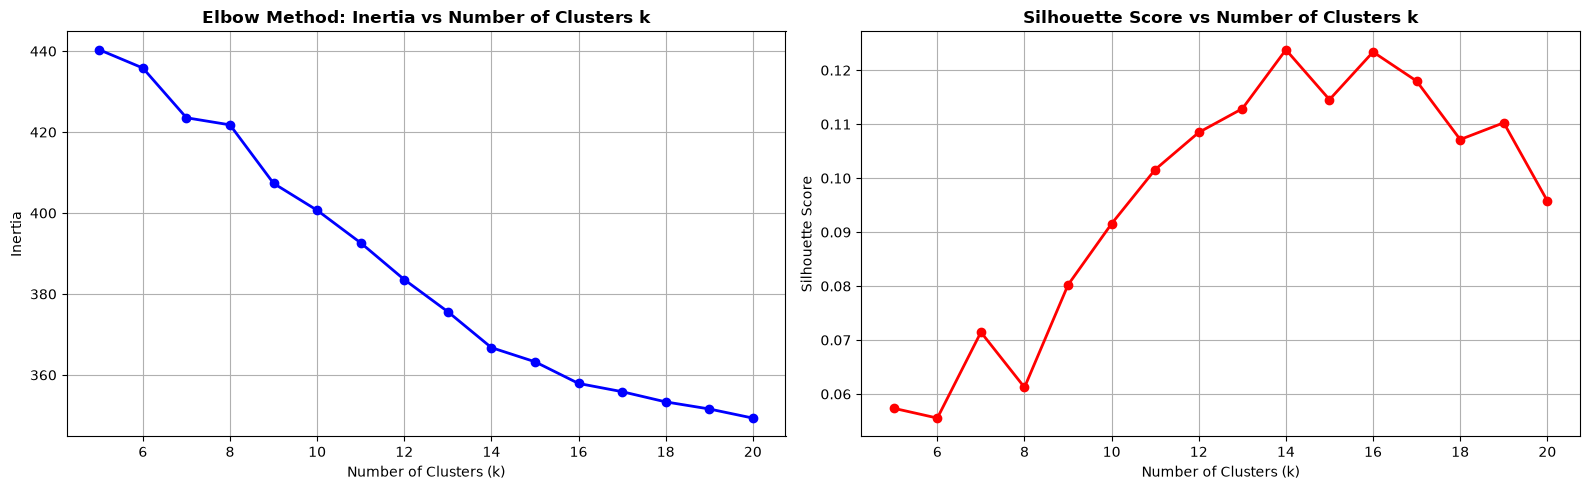

Optimal k by Silhouette: k = 14 (Silhouette = 0.1238)


In [2]:
k_vals = list(range(5, 21))
inertias = [440.3392850723143, 435.8220022118873, 423.54050939383046, 421.7800587934522, 407.3309656750823, 400.6785677863122, 392.6276917733537, 383.5592834817595, 375.6177316448458, 366.7506293699787, 363.2548741681327, 357.90026143732973, 355.864569837115, 353.3422355447736, 351.5942360579238, 349.3418622160749]
silhouettes = [0.05735301253554375, 0.055537182611216165, 0.07145462473019461, 0.061227109450485005, 0.08022548844543957, 0.09156355759685636, 0.10159934691781904, 0.1084738787254274, 0.112876653420204, 0.12379355080727614, 0.11455081240276231, 0.123384148763867, 0.11799309001520487, 0.10715756391747033, 0.1102630512036871, 0.09579224962954919]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Elbow Method
ax1.plot(k_vals, inertias, 'bo-', linewidth=2, markersize=6)
ax1.set_title("Elbow Method: Inertia vs Number of Clusters k", weight='bold')
ax1.set_xlabel("Number of Clusters (k)")
ax1.set_ylabel("Inertia")
ax1.grid(True)

# Silhouette Score
ax2.plot(k_vals, silhouettes, 'ro-', linewidth=2, markersize=6)
ax2.set_title("Silhouette Score vs Number of Clusters k", weight='bold')
ax2.set_xlabel("Number of Clusters (k)")
ax2.set_ylabel("Silhouette Score")
ax2.grid(True)

plt.tight_layout()
plt.show()

print(f"Optimal k by Silhouette: k = 14 (Silhouette = 0.1238)")


## 2. 2D Manifold Visualizations: PCA & t-SNE
Mapping the high-dimensional TF-IDF vector space into two dimensions.


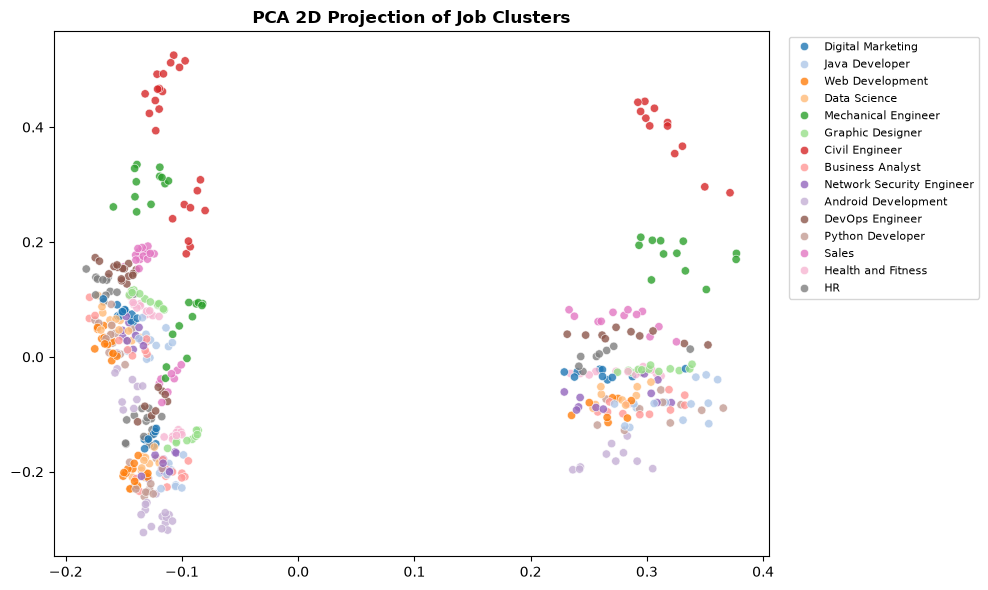

In [3]:
# Fit final model with k=15
cluster_engine = JobClusterEngine(k=15, random_state=42)
df_clustered = cluster_engine.fit(df, vectorizer=vectorizer)

# PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X.toarray())

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df_clustered['Category'], palette='tab20', alpha=0.8)
plt.title("PCA 2D Projection of Job Clusters", weight='bold')
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()


## 3. Skill-Gap Diagnostic Module in Action
Testing the candidate skill-gap report:
- Maps candidate to nearest cluster centroid
- Calculates Readiness Score (% overlap against cluster core skills)
- Produces a concise, single-sentence career guidance action item highlighting the single biggest gap to close.


In [4]:
test_resume = """
Aspiring Data Scientist with foundational skills in Python and SQL.
Completed projects in Pandas data cleaning and basic exploratory data analysis.
Looking for junior analytical and machine learning roles.
"""

gap_report = cluster_engine.get_skill_gap_report(test_resume)

print("="*65)
print(f"Target Cluster Role: {gap_report['target_role_domain']}")
print(f"Candidate Skills Found: {gap_report['candidate_skills']}")
print(f"Cluster Core Competencies: {gap_report['cluster_core_skills']}")
print(f"Matched Skills: {gap_report['matched_skills']}")
print(f"Missing Skills: {gap_report['missing_skills']}")
print(f"Readiness Score: {gap_report['readiness_score']}%")
print(f"Recommendation: {gap_report['single_line_explanation']}")
print("="*65)


Target Cluster Role: Data Science
Candidate Skills Found: ['Machine Learning', 'Pandas', 'Python', 'SQL']
Cluster Core Competencies: ['Excel', 'Scikit-learn', 'A/B Testing', 'SQL', 'Tableau', 'Python', 'Data Visualization', 'Pandas', 'TensorFlow', 'NumPy']
Matched Skills: ['Pandas', 'Python', 'SQL']
Missing Skills: ['A/B Testing', 'Data Visualization', 'Excel', 'NumPy', 'Scikit-learn', 'Tableau', 'TensorFlow']
Readiness Score: 30.0%
Recommendation: Single biggest gap to close: Master A/B Testing to elevate role readiness from 30.0% to 40.0% for Data Science.
